<font color="#2E86C1" size="6">Manufacturing Defect Cost Analysis</font>

<font color="#4682B4" size="5">Problem Statement</font>
<br>
In a high-precision manufacturing environment, maintaining quality while controlling repair costs is critical to operational efficiency. Currently, the production team categorizes defects by Severity, Location, and Type. Company leadership wants to know which areas concerning product defects would be most effecient to focus on improving.

The goal of this analysis is to:

1. Identify Cost Drivers: Determine which severity level, defect type, or defect location is the most problematic and which would be the most effecient to focus on improving.

2. Provide Data-Driven Recommendations: Assist leadership in prioritizing which aspects of the defects should be focused on to have the optimal impact on reducing loss due to defects.

<font color="#4682B4" size="5">Import</font><br>
Importing defect_list file that was downloaded from BigQuery after performing initial SQL query.

<font color="#4682B4" size="4">NOTE:</font> The SQL query is not completely necessary for this particular dataset, since there are only 1000 rows. The query reduced the rows down to 851, however the initial raw data could potentially be much larger, and the SQL query would be much more useful at that point to average all repair costs of all similar instances together before working with the data using Python. Process was performed to simulate a much larger dataset.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
defects = pd.read_csv('defect_list.csv')

<font color="#4682B4" size="5">Data Cleaning</font><br>

In [5]:
defects.isnull().sum()

product_id           0
defect_type          0
defect_location      0
severity             1
avg_repair_cost      1
occurrence_count     0
total_repair_cost    1
dtype: int64

In [6]:
defects[defects['severity'].isnull()]

,product_id,defect_type,defect_location,severity,avg_repair_cost,occurrence_count,total_repair_cost
10,2,Structural,Component,NaN,478.44,1,478.44


- Further investigation of this missing severity value concluded that this was a critical defect, the data will be updated accordingly.

In [7]:
defects['severity'] = defects['severity'].fillna('Critical')
defects.isnull().sum()

product_id           0
defect_type          0
defect_location      0
severity             0
avg_repair_cost      1
occurrence_count     0
total_repair_cost    1
dtype: int64

In [8]:
defects[defects['avg_repair_cost'].isnull()]

,product_id,defect_type,defect_location,severity,avg_repair_cost,occurrence_count,total_repair_cost
185,22,Functional,Internal,Critical,NaN,1,NaN


- Further investigation of this missing repair cost value could not determine the cost. Approval was given to assign the average cost of all other functional, internal, critical defects.

In [9]:
group_avg = defects[
    (defects['defect_type'] == 'Functional') & 
    (defects['defect_location'] == 'Internal') & 
    (defects['severity'] == 'Critical')
]['avg_repair_cost'].mean()
#Since the occurrence_count for this row is 1, the avg_repair_cost is equal to the total_repair_cost
defects['avg_repair_cost'] = defects['avg_repair_cost'].fillna(group_avg).round(2)
defects['total_repair_cost'] = defects['total_repair_cost'].fillna(defects['avg_repair_cost'] * defects['occurrence_count']).round(2)
display(defects.iloc[[185]])

,product_id,defect_type,defect_location,severity,avg_repair_cost,occurrence_count,total_repair_cost
185,22,Functional,Internal,Critical,494.02,1,494.02


In [10]:
defects.describe()

,product_id,avg_repair_cost,occurrence_count,total_repair_cost
count,851.000000,851.000000,851.000000,851.000000
mean,50.720329,510.278790,1.175088,595.916063
std,29.574342,278.176435,0.418558,376.887459
min,1.000000,10.440000,1.000000,10.440000
25%,26.000000,291.595000,1.000000,310.335000
50%,50.000000,503.240000,1.000000,565.860000
75%,77.000000,748.650000,1.000000,828.615000
max,100.000000,999.640000,3.000000,2489.350000


- Null values have been accounted for. Ranges for all numerical columns appear in order.

<font color="#4682B4" size="5">Exploratory Data Analysis</font><br>

In [11]:
defects.head()

,product_id,defect_type,defect_location,severity,avg_repair_cost,occurrence_count,total_repair_cost
0,1,Structural,Surface,Critical,564.46,1,564.46
1,1,Cosmetic,Surface,Critical,306.49,2,612.97
2,1,Structural,Component,Critical,192.21,1,192.21
3,1,Cosmetic,Component,Critical,959.70,2,1919.40
4,1,Structural,Component,Moderate,856.33,1,856.33


In [12]:
defects.info()

<class 'pandas.DataFrame'>
RangeIndex: 851 entries, 0 to 850
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   product_id         851 non-null    int64  
 1   defect_type        851 non-null    str    
 2   defect_location    851 non-null    str    
 3   severity           851 non-null    str    
 4   avg_repair_cost    851 non-null    float64
 5   occurrence_count   851 non-null    int64  
 6   total_repair_cost  851 non-null    float64
dtypes: float64(2), int64(2), str(3)
memory usage: 46.7 KB


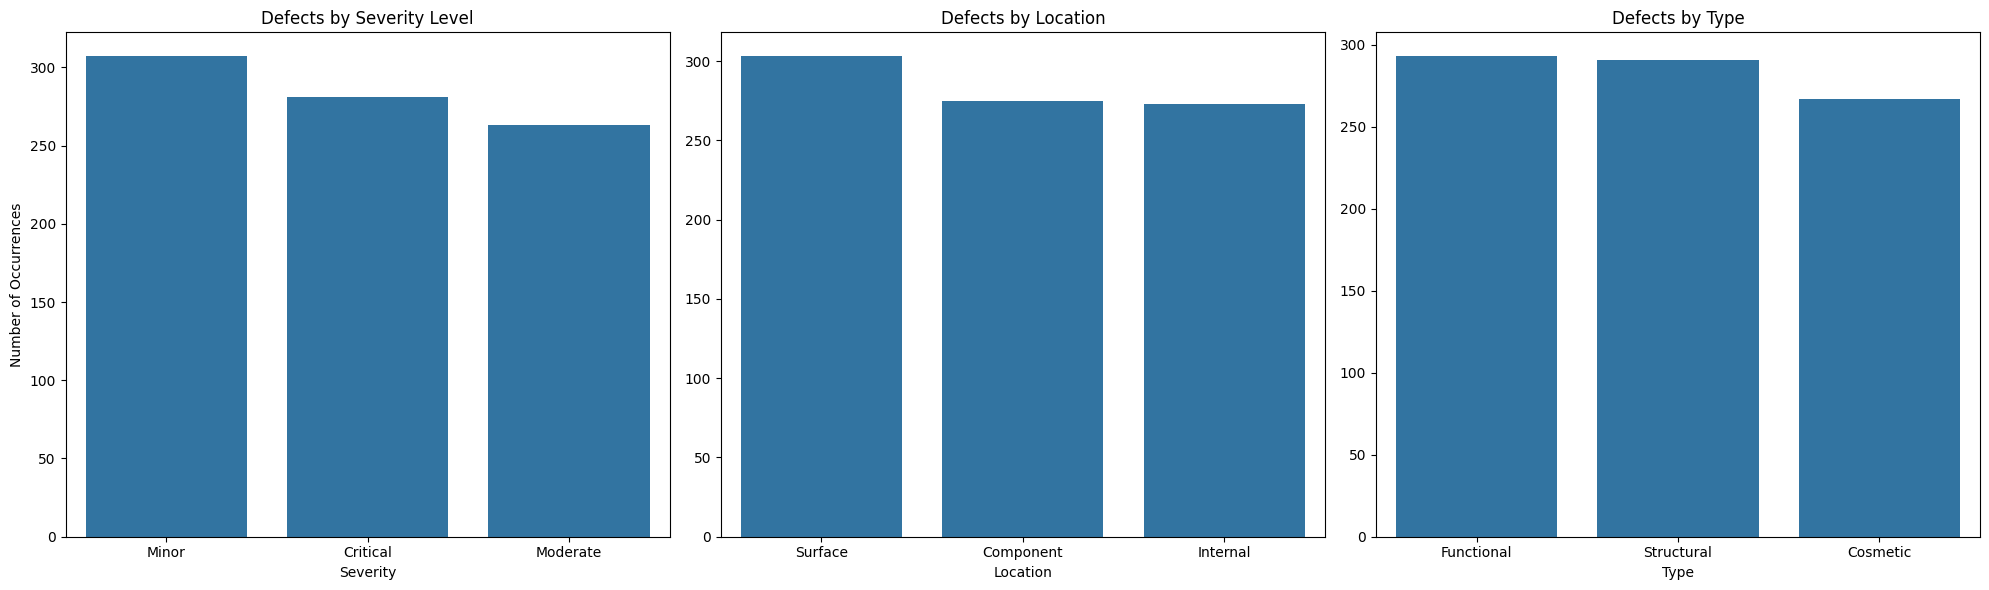

In [13]:
# Checking distribution of severity, location and type
plt.figure(figsize=(20, 6))

# 1. Severity Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=defects, x='severity',order=defects['severity'].value_counts().index)
plt.title('Defects by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Number of Occurrences')

# 2. Location Distribution
plt.subplot(1, 3, 2)
sns.countplot(data=defects, x='defect_location', order=defects['defect_location'].value_counts().index)
plt.title('Defects by Location')
plt.xlabel('Location')
plt.ylabel('')

# 3. Type Distribution
plt.subplot(1, 3, 3)
sns.countplot(data=defects, x='defect_type', order=defects['defect_type'].value_counts().index)
plt.title('Defects by Type')
plt.xlabel('Type')
plt.ylabel('')

plt.tight_layout()
plt.show()

- Minor defects are most frequent, as expected. However, critical defects are just under minor, and more frequent than moderate.
- surface defects slightly more frequent, and functional/structural defects slightly more frequent. No one location or type stands out as a major contributor to defects.

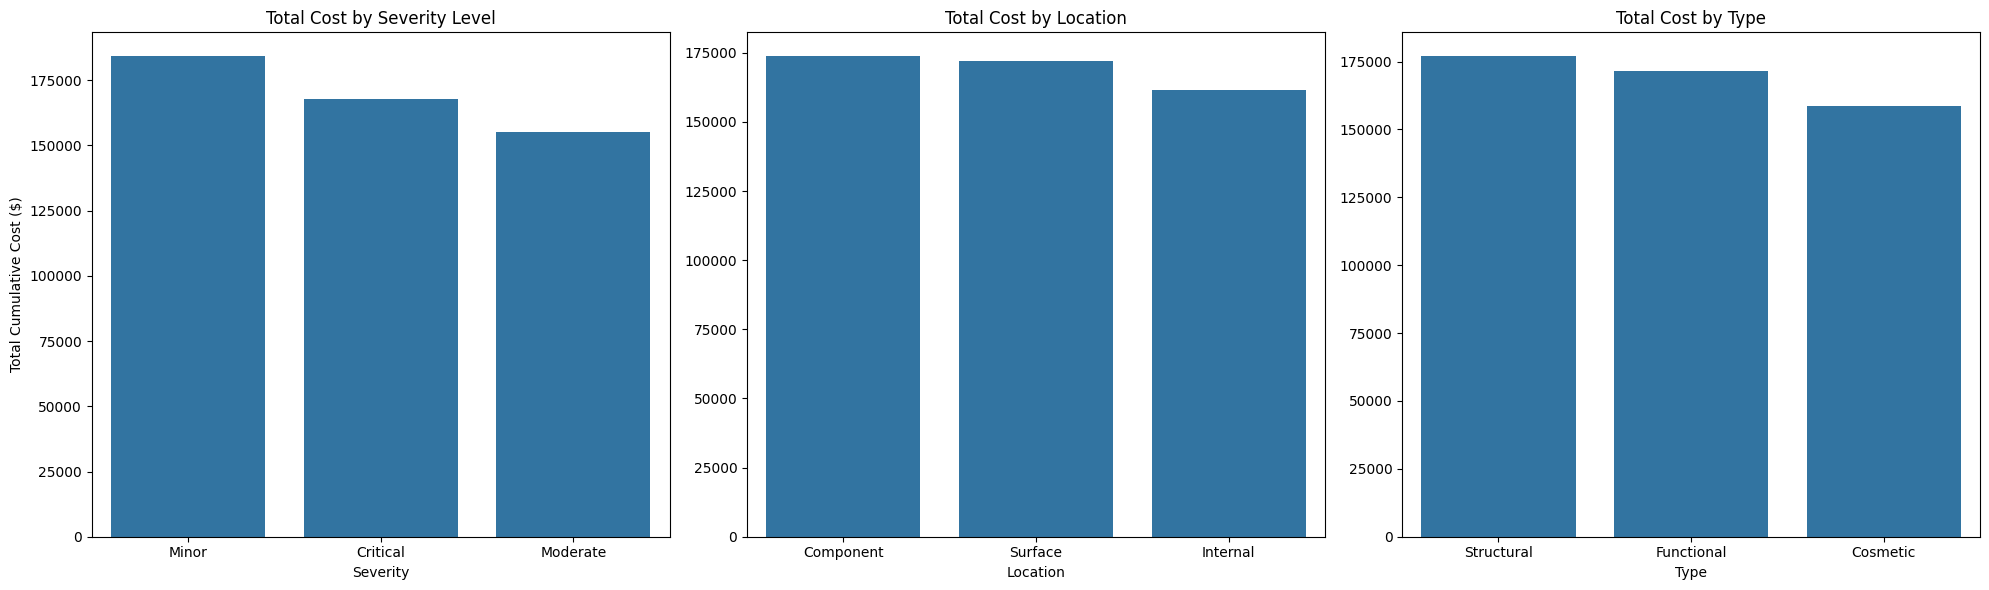

In [14]:
# Checking total repair spend across severity, location and type
plt.figure(figsize=(20, 6))

# 1. Total Spend by Severity
plt.subplot(1, 3, 1)
sns.barplot(data=defects, x='severity', y='total_repair_cost', 
            estimator=sum, errorbar=None,
            order=defects.groupby('severity')['total_repair_cost'].sum().sort_values(ascending=False).index)
plt.title('Total Cost by Severity Level')
plt.xlabel('Severity')
plt.ylabel('Total Cumulative Cost ($)')

# 2. Total Spend by Location
plt.subplot(1, 3, 2)
sns.barplot(data=defects, x='defect_location', y='total_repair_cost', 
            estimator=sum, errorbar=None,
            order=defects.groupby('defect_location')['total_repair_cost'].sum().sort_values(ascending=False).index)
plt.title('Total Cost by Location')
plt.xlabel('Location')
plt.ylabel('')

# 3. Total Spend by Type
plt.subplot(1, 3, 3)
sns.barplot(data=defects, x='defect_type', y='total_repair_cost', 
            estimator=sum, errorbar=None,
            order=defects.groupby('defect_type')['total_repair_cost'].sum().sort_values(ascending=False).index)
plt.title('Total Cost by Type')
plt.xlabel('Type')
plt.ylabel('')

plt.tight_layout()
plt.show()

- Contrary to expectation, minor defects have a higher cumulative cost than both critical and moderate.
- Again, no single type or location stands out as a major contributor to defects.

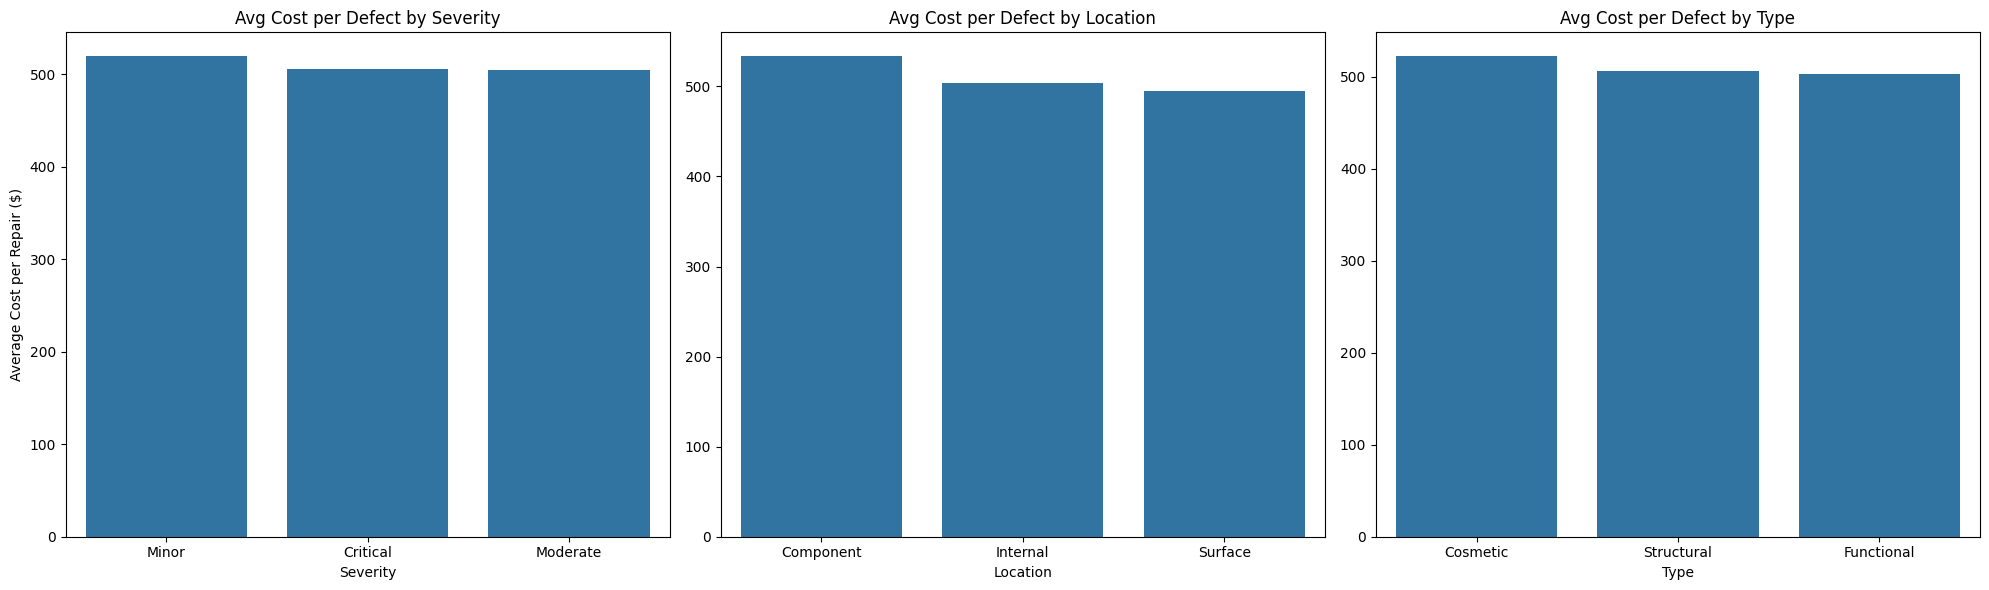

In [15]:
# Checking average cost per individual defect across severity, location and type
plt.figure(figsize=(20, 6))

# 1. Average Cost by Severity
plt.subplot(1, 3, 1)
sns.barplot(data=defects, x='severity', y='avg_repair_cost', 
            estimator='mean', errorbar=None,
            order=defects.groupby('severity')['avg_repair_cost'].mean().sort_values(ascending=False).index)
plt.title('Avg Cost per Defect by Severity')
plt.xlabel('Severity')
plt.ylabel('Average Cost per Repair ($)')

# 2. Average Cost by Location
plt.subplot(1, 3, 2)
sns.barplot(data=defects, x='defect_location', y='avg_repair_cost', 
            estimator='mean', errorbar=None,
            order=defects.groupby('defect_location')['avg_repair_cost'].mean().sort_values(ascending=False).index)
plt.title('Avg Cost per Defect by Location')
plt.xlabel('Location')
plt.ylabel('')

# 3. Average Cost by Type
plt.subplot(1, 3, 3)
sns.barplot(data=defects, x='defect_type', y='avg_repair_cost', 
            estimator='mean', errorbar=None,
            order=defects.groupby('defect_type')['avg_repair_cost'].mean().sort_values(ascending=False).index)
plt.title('Avg Cost per Defect by Type')
plt.xlabel('Type')
plt.ylabel('')

plt.tight_layout()
plt.show()

- In line total average cost, minor defects also have the largest average cost per defect repair.
- Again, no single type or location stands out as a major contributor to defects.

In [17]:
defects.to_csv('cleaned_manufacturing_defects.csv', index=False)

<font color='#2E86C1' size='6'>Conclusions</font>
- Initial assumption would be that minor severity defects would be more frequent but cheaper to repair, while critical defects would be less frequent but more expensive to repair.
- After analysis, it shows that while minor defects are slightly more frequent than critical, they are actually more costly to repair, both cumulatively and per defect.
- Concerning defect type and location, no value stands out as either considerably more frequent or more costly.

<font color='#2E86C1' size='6'>Recommendations</font>
- Minor defects: first determine why minor defects are so costly to repair. This may be due to a standard operating procedure issue or a misunderstanding of how these defects aught to be repaired. It may be possible to bring cost or minor repairs down so that even if they are still frequent, they will not be as costly.
- Critical defects: determine why there is such a large occurrence of critical defects. reinforced training or more robust SOPs may reduce the occurrence of these critical defects.